In [2]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [3]:
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [4]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [5]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

### Download Data

First, I will download the necessary CSV files from a public source to the local `data` directory to resolve the `FileNotFoundError`.

In [6]:
import os
import requests

# Create the 'data' directory if it doesn't exist
if not os.path.exists('./data'):
    os.makedirs('./data')

def download_file(url, destination):
    response = requests.get(url, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(destination, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Downloaded {os.path.basename(destination)}")

# Define the URLs for the datasets
rainfall_url = 'https://raw.githubusercontent.com/zikmundmartin7-lab/Rainfall/main/data/Rainfall.csv'
train_url = 'https://raw.githubusercontent.com/zikmundmartin7-lab/Rainfall/main/data/train.csv'
test_url = 'https://raw.githubusercontent.com/zikmundmartin7-lab/Rainfall/main/data/test.csv'

# Define destination paths
rainfall_dest = './data/Rainfall.csv'
train_dest = './data/train.csv'
test_dest = './data/test.csv'

# Download files
download_file(rainfall_url, rainfall_dest)
download_file(train_url, train_dest)
download_file(test_url, test_dest)

Downloaded Rainfall.csv
Downloaded train.csv
Downloaded test.csv


In [7]:
rain_file_origin_path = './data/Rainfall.csv'
rain_origin_data = pd.read_csv(rain_file_origin_path)
rain_file_path = './data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "./data/test.csv"
test_data = pd.read_csv(test_file_path)

In [8]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [9]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [10]:
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [11]:
y_origin = rain_origin_data["rainfall"]

In [12]:
X_origin = rain_origin_data.drop(labels="rainfall", axis=1)

In [13]:
X_origin = X_origin.drop(labels="day", axis=1)
X_test = X_test.drop(labels="day", axis=1)

In [14]:
X = X.drop(labels="id", axis=1)
X_test = X_test.drop(labels="id", axis=1)

In [15]:
X = X.drop(labels="day", axis=1)

In [16]:
X_origin.rename(columns={'pressure ': 'pressure', 'humidity ': 'humidity', '         winddirection': 'winddirection', 'cloud ':'cloud' }, inplace=True)

In [17]:

y_origin = y_origin.replace({"yes": 1, "no": 0})

/tmp/ipykernel_2213/425826855.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_origin = y_origin.replace({"yes": 1, "no": 0})


In [18]:
y_origin

,rainfall
0,1
1,1
2,1
3,1
4,1
...,...
361,1
362,1
363,1
364,1


In [19]:
X = pd.concat([X, X_origin], ignore_index=True)
y = pd.concat([y, y_origin], ignore_index=True)

In [20]:
X.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0
winddirection,1
windspeed,1


In [21]:
winddirection_nan = X.winddirection.isnull()
winddirection_nan.loc[winddirection_nan == True]

,winddirection
2350,True


In [22]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,NaN,NaN
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [23]:
X.winddirection.fillna(205.0, inplace=True)

/tmp/ipykernel_2213/1166324537.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.winddirection.fillna(205.0, inplace=True)


In [24]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,205.0,NaN
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [25]:
X.windspeed.fillna(13.6, inplace=True)

/tmp/ipykernel_2213/3718298068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.windspeed.fillna(13.6, inplace=True)


In [26]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,205.0,13.6
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [27]:
y

,rainfall
0,1
1,1
2,1
3,1
4,0
...,...
2551,1
2552,1
2553,1
2554,1


In [28]:
#train2_1 = X
#train2_1["rainfall"] = y
#train2_1.to_csv('train2_1.csv')
#train2_1

In [29]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI Scores
cloud,0.225528
sunshine,0.177870
humidity,0.146522
dewpoint,0.041666
maxtemp,0.035362
temparature,0.023822
mintemp,0.022473
pressure,0.018506
windspeed,0.017216
winddirection,0.000000


In [30]:
#cols = X.columns
cols = ["cloud", "sunshine", "humidity"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity
0,88.0,1.1,87.0
1,91.0,0.0,95.0
2,47.0,8.3,75.0
3,95.0,0.0,95.0
4,45.0,3.6,52.0
...,...,...,...
2551,90.0,0.0,84.0
2552,85.0,1.0,75.0
2553,78.0,4.6,75.0
2554,86.0,1.2,78.0


In [31]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity
0,0.88,0.090909,0.822581
1,0.91,0.000000,0.951613
2,0.47,0.685950,0.629032
3,0.95,0.000000,0.951613
4,0.45,0.297521,0.258065
...,...,...,...
2551,0.90,0.000000,0.774194
2552,0.85,0.082645,0.629032
2553,0.78,0.380165,0.629032
2554,0.86,0.099174,0.677419


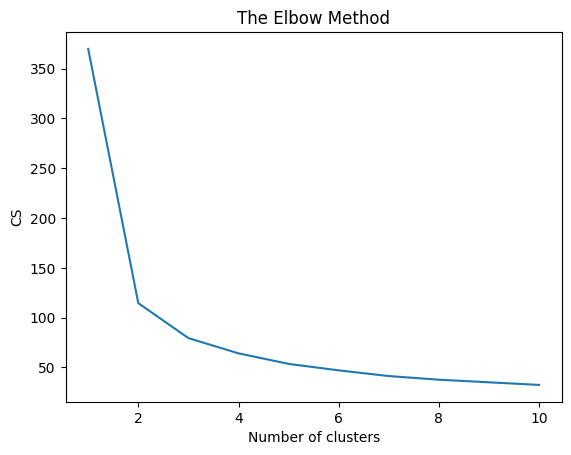

In [32]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [33]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 2010 out of 2556 samples were correctly labeled.
Accuracy score: 0.79


In [34]:
kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1769 out of 2556 samples were correctly labeled.
Accuracy score: 0.69


In [35]:
kmeans = KMeans(n_clusters=4, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 201 out of 2556 samples were correctly labeled.
Accuracy score: 0.08


In [36]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)

In [37]:
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [38]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [39]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [40]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,Centroid_2,Centroid_3,cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,1.320341,0.056520,2.007102,1.129598,2
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,1.407167,0.130278,2.026009,1.196523,2
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0.115013,1.279077,1.161717,2.018923,1
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,1.421584,0.143364,2.028284,1.203794,2
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2.087429,1.258515,3.059902,0.581229,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,1.382251,0.068363,2.018801,1.179877,2
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,1.382251,0.068363,2.018801,1.179877,2
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,1.355580,0.154279,2.012933,1.161501,2
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,1.355553,0.139580,2.013082,1.164626,2


In [41]:
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [42]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI Scores
Centroid_2,0.221817
Centroid_3,0.208909
Centroid_1,0.204401
Centroid_0,0.196879
cloud,0.196587
cluster,0.186625
sunshine,0.166513
humidity,0.123925
temparature,0.033474
dewpoint,0.029429


In [43]:
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [44]:
X = X.drop(labels = ("winddirection"), axis=1)
X_test = X_test.drop(labels = ("winddirection"), axis=1)
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [45]:
#X = X.drop(labels = ("winddirection"), axis=1)
#X_test = X_test.drop(labels = ("winddirection"), axis=1)
#score_dataset(X, y)

In [46]:
features = ["cloud", "cluster", "Centroid_1", "Centroid_0", "humidity", "sunshine", "Centroid_2", "Centroid_3", "temparature"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                  PC1       PC2       PC3       PC4       PC5       PC6  \
cloud        0.246515 -0.487408  0.192045  0.165982 -0.209290  0.762824   
cluster      0.441442  0.281776 -0.017045  0.014616  0.017822  0.020891   
Centroid_1  -0.393216  0.069186  0.339809  0.471894  0.354418 -0.002014   
Centroid_0   0.349235 -0.096436  0.389167  0.597849  0.109523 -0.305135   
humidity     0.226617 -0.357567  0.295190 -0.520507  0.674351 -0.082529   
sunshine    -0.190023  0.546749  0.092736 -0.019959  0.387451  0.557362   
Centroid_2   0.426132  0.316634 -0.039976  0.014166  0.031554  0.015563   
Centroid_3  -0.435831 -0.295038  0.004306 -0.011499 -0.020811 -0.045985   
temparature -0.093673  0.234214  0.773662 -0.347088 -0.460410 -0.068780   

                  PC7       PC8       PC9  
cloud        0.096342  0.047357 -0.002351  
cluster      0.227760 -0.060411  0.817893  
Centroid_1   0.606597  0.092545  0.017288  
Centroid_0  -0.499590 -0.069478 -0.018445  
humidity     0.030952  0.0139

In [47]:
X = X.join(X_pca)
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,Centroid_0,...,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1.320341,...,2,1.649129,-0.814827,-0.629991,-0.470212,-0.108108,0.101412,-0.103877,-0.044184,-0.010859
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1.407167,...,2,2.026501,-1.591609,-0.789830,-0.568686,0.773418,-0.023994,0.024834,0.036354,0.005604
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,0.115013,...,1,-2.024892,1.169491,-2.181765,-0.350042,0.784836,0.257251,0.158468,-0.073124,0.005170
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1.421584,...,2,2.063191,-1.658734,-0.601478,-0.569410,0.658819,0.119705,0.043654,0.055994,0.007902
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,2.087429,...,3,0.971023,2.845872,-1.607550,3.067302,-1.295793,-1.241695,0.048651,0.201004,0.196411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1022.7,18.8,17.7,16.9,15.0,84.0,90.0,0.0,18.4,1.370280,...,2,1.711249,-1.045240,-1.132215,-0.007905,-0.227388,0.056299,-0.030705,-0.010342,0.002141
2552,1026.6,18.6,17.3,16.3,12.8,75.0,85.0,1.0,25.9,1.296168,...,0,-2.103660,-1.861383,-0.622095,1.578385,-0.023374,-0.019698,0.098540,0.029121,-0.011378
2553,1025.9,18.9,17.7,16.4,13.3,75.0,78.0,4.6,33.4,1.137906,...,0,-2.474921,-1.078640,-0.638646,1.326518,0.385213,0.320123,-0.187305,-0.032921,-0.019073
2554,1025.3,19.2,17.3,15.2,13.3,78.0,86.0,1.2,20.9,1.292586,...,0,-2.031540,-1.998739,-0.501354,1.388888,0.230081,0.022691,0.087951,0.004385,-0.002563


In [48]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [49]:
#když bylo vyhozené id a day bylo to 0.8745862843729195
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [50]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI Scores
Centroid_2,0.222008
cloud,0.218239
Centroid_3,0.206898
Centroid_1,0.206437
Centroid_0,0.199142
cluster,0.198548
sunshine,0.165697
PC2,0.147356
humidity,0.145527
PC1,0.093187


In [51]:
X = X.drop(labels = ("PC5"), axis=1)
X_test = X_test.drop(labels = ("PC5"), axis=1)
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [52]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
score_dataset(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: U

nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2283, in _check_response_method
    raise AttributeError(
AttributeError: RandomForestRegressor has none of the following attributes: decision_function, predict_proba.

  warnings.warn(


In [53]:
model=RandomForestRegressor(random_state=1)
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8932952208073243


In [55]:
%%time
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression,
    parameters,
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' +
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

-----
Best parameters {'C': 0.01, 'penalty': 'l2'}
Mean cross-validated accuracy score of the best_estimator: 0.894
-----
CPU times: user 6.64 s, sys: 13.5 ms, total: 6.65 s
Wall time: 8.45 s


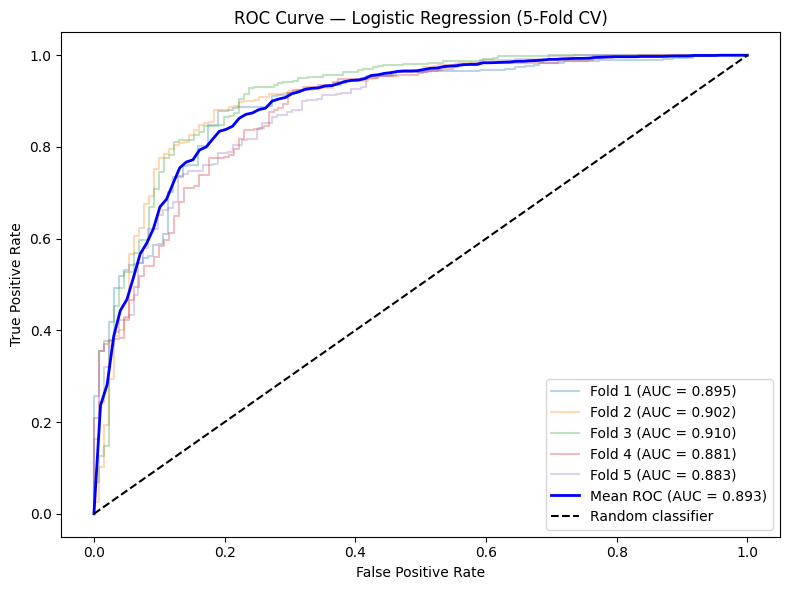

In [56]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

# Create the directory if it doesn't exist
output_dir = "../reports/figures"
os.makedirs(output_dir, exist_ok=True)

model_roc = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

cv = StratifiedKFold(n_splits=5)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(8, 6))

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    model_roc.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = model_roc.predict_proba(X.iloc[val_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y.iloc[val_idx], y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    ax.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold+1} (AUC = {roc_auc:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

ax.plot(mean_fpr, mean_tpr, color="blue", lw=2,
        label=f"Mean ROC (AUC = {mean_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression (5-Fold CV)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [57]:
model_logistic_regression = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

In [58]:
model_logistic_regression.fit(X, y)
rf_test_preds = model_logistic_regression.predict(X_test)

In [59]:
X_test["id"] = test_data["id"]
X_test["rainfall"] = rf_test_preds
X_test.to_csv('submission_2dts_k-mean_PCA_4_clusters.csv', columns=['id','rainfall'], index=False)

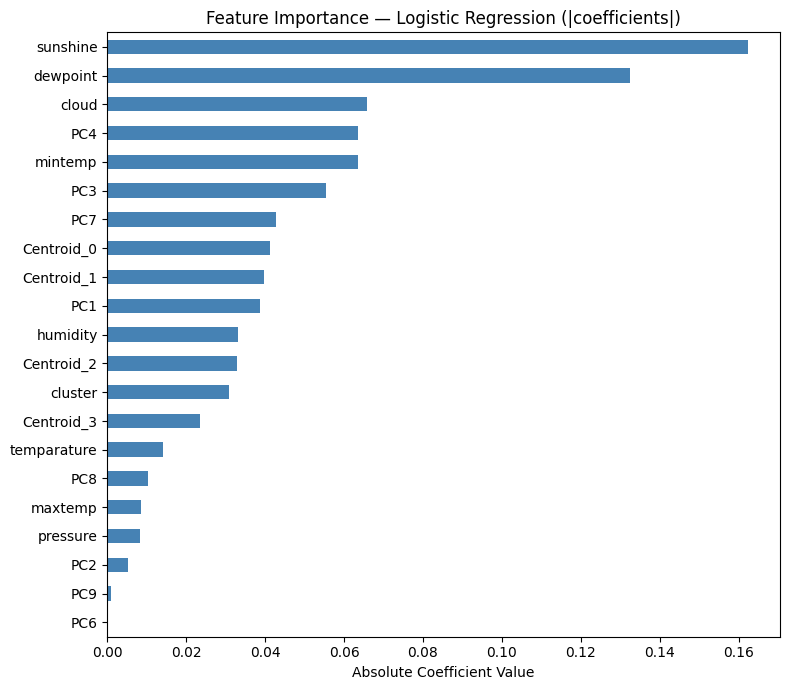

In [60]:
# Fit modelu na všechna data
model_logistic_regression.fit(X, y)

# Koeficienty
coef = pd.Series(
    np.abs(model_logistic_regression.coef_[0]),  # absolutní hodnota = důležitost
    index=X.columns
).sort_values(ascending=True)

# Graf
fig, ax = plt.subplots(figsize=(8, 7))
coef.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance — Logistic Regression (|coefficients|)")
ax.set_xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

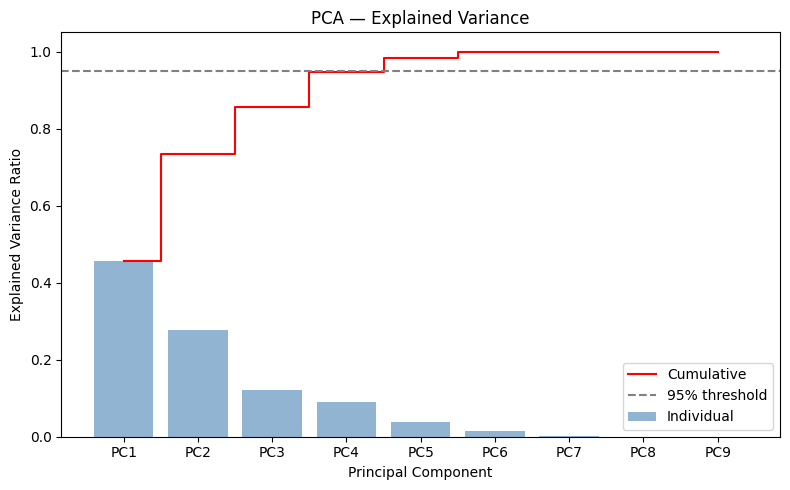

In [61]:
# PCA variance explained
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.6,
       color="steelblue", label="Individual")
ax.step(range(1, len(explained) + 1), cumulative, where="mid",
        color="red", label="Cumulative")
ax.axhline(y=0.95, color="gray", linestyle="--", label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Explained Variance")
ax.set_xticks(range(1, len(explained) + 1))
ax.set_xticklabels([f"PC{i}" for i in range(1, len(explained) + 1)])
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

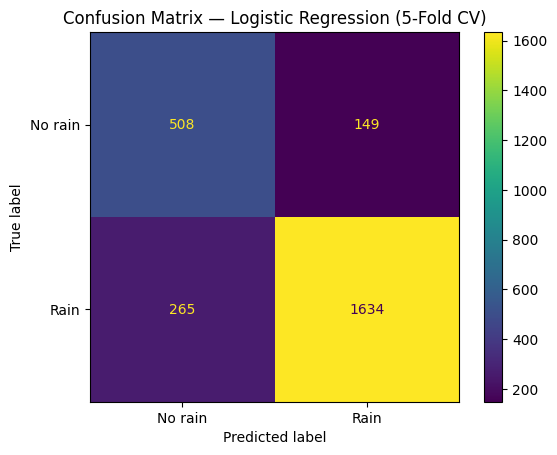

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model_logistic_regression, X, y, cv=5)
ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=["No rain", "Rain"])
plt.title("Confusion Matrix — Logistic Regression (5-Fold CV)")
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()